# Titanic Survival Prediction — EDA & Modeling

This notebook walks through a full workflow on the Titanic dataset (Kaggle "Titanic: Machine Learning from Disaster"):

1. Exploratory Data Analysis (missing values, target vs. features, correlation, statistical tests)
2. Data cleaning & feature engineering
3. Baseline modeling with `LinearSVC`
4. Hyperparameter tuning (manual, `RandomizedSearchCV`, `GridSearchCV`)
5. A tree-based model (`RandomForestClassifier`) for comparison
6. Final results & discussion

**Goal:** predict whether a passenger survived (`Survived`: 0 = No, 1 = Yes) based on passenger attributes.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


## 1. Load the data

In [3]:
df_train = pd.read_csv('train.csv')
print(df_train.shape)
df_train.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploratory Data Analysis

### 2.1 Missing values

Before doing anything else, we check *how much* is missing and, importantly, *whether the missingness itself is informative* rather than jumping straight to imputation.


In [4]:
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train) * 100).round(1)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)
missing_summary[missing_summary['missing_count'] > 0]


,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


**Findings:**
- `Cabin`: 77.1% missing — too sparse to impute reliably. We'll check whether missingness itself carries a signal before deciding what to do with it.
- `Age`: 19.9% missing — worth imputing thoughtfully (grouped, not just a single global value).
- `Embarked`: 0.2% missing (2 rows) — trivial, mode-fill is fine.


### 2.2 Target vs. features

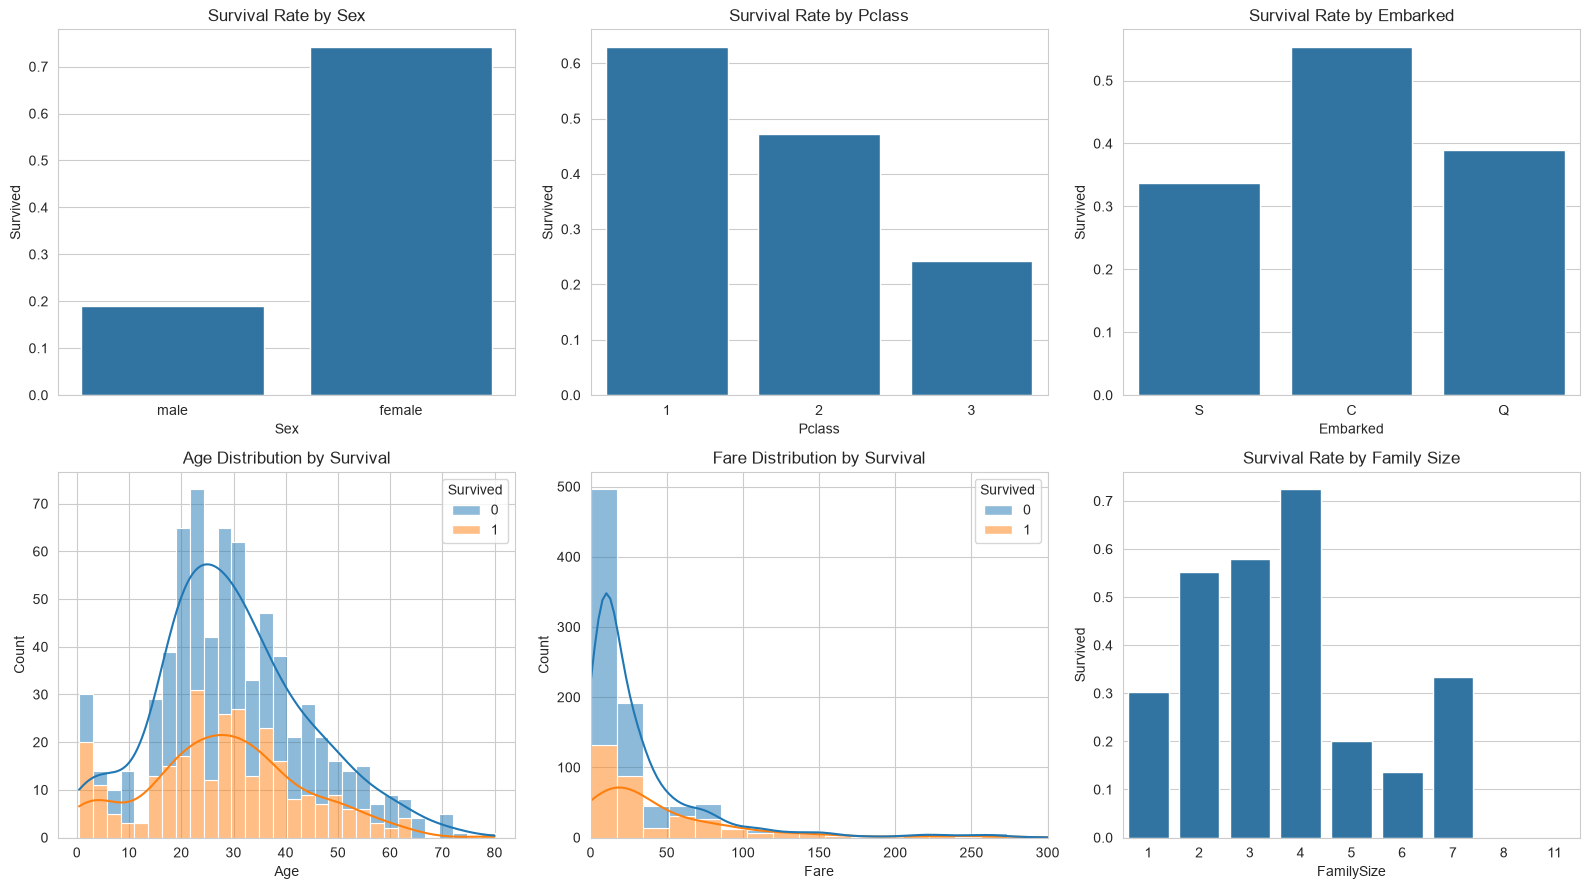

In [5]:
df_eda = df_train.copy()
df_eda['FamilySize'] = df_eda['SibSp'] + df_eda['Parch'] + 1

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.barplot(data=df_eda, x='Sex', y='Survived', ax=axes[0,0], errorbar=None); axes[0,0].set_title('Survival Rate by Sex')
sns.barplot(data=df_eda, x='Pclass', y='Survived', ax=axes[0,1], errorbar=None); axes[0,1].set_title('Survival Rate by Pclass')
sns.barplot(data=df_eda, x='Embarked', y='Survived', ax=axes[0,2], errorbar=None); axes[0,2].set_title('Survival Rate by Embarked')
sns.histplot(data=df_eda, x='Age', hue='Survived', kde=True, bins=30, ax=axes[1,0], multiple='stack'); axes[1,0].set_title('Age Distribution by Survival')
sns.histplot(data=df_eda, x='Fare', hue='Survived', kde=True, bins=30, ax=axes[1,1], multiple='stack'); axes[1,1].set_xlim(0, 300); axes[1,1].set_title('Fare Distribution by Survival')
sns.barplot(data=df_eda, x='FamilySize', y='Survived', ax=axes[1,2], errorbar=None); axes[1,2].set_title('Survival Rate by Family Size')

plt.tight_layout()
plt.show()


**Findings:**
- **Sex** - the strongest visible signal and women survived at a much higher rate than men.
- **Pclass** — 1st class survived more than 3rd class.
- **Embarked** — passengers who boarded at Cherbourg (C) survived more, likely confounded with class/fare.
- **Age** — young children show a survival bump, otherwise the distributions overlap heavily.
- **Fare** — higher fares (proxy for class) skew toward survival.
- **Family size** — solo travelers and individuals with very large families on board survived less than individuals with small families (2-4 members).


### 2.3 Correlation

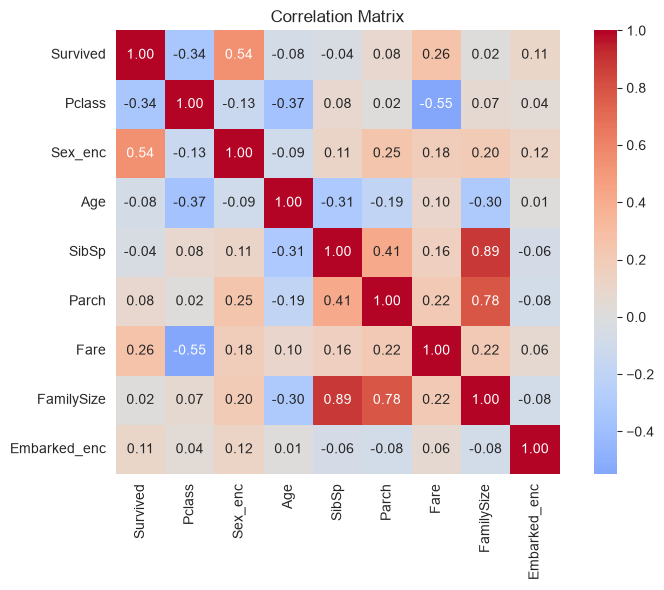

Survived        1.000000
Sex_enc         0.543351
Fare            0.257307
Embarked_enc    0.108669
Parch           0.081629
FamilySize      0.016639
SibSp          -0.035322
Age            -0.077221
Pclass         -0.338481
Name: Survived, dtype: float64

In [6]:
df_corr = df_eda.copy()
df_corr['Sex_enc'] = df_corr['Sex'].map({'male': 0, 'female': 1})
df_corr['Embarked_enc'] = df_corr['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

corr_cols = ['Survived', 'Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Embarked_enc']
corr = df_corr[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

corr['Survived'].sort_values(ascending=False)


`Sex_enc` (0.54), `Pclass` (-0.34), and `Fare` (0.26) show the strongest linear relationships with `Survived`. Note: Pearson correlation only captures *linear* relationships and treats `Embarked_enc` as if it were ordinal (0/1/2), which it isn't. That's why we follow up with a chi-square test below for a more appropriate read on categorical associations.


### 2.4 Cabin: is the missingness informative?

Rather than dropping `Cabin` outright, we check whether *having* a recorded cabin (regardless of which one) relates to survival. This determines whether we engineer a feature from it before dropping the raw column.


C:\Users\ytgpm\AppData\Local\Temp\ipykernel_7748\1797174892.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['No Cabin', 'Has Cabin'])


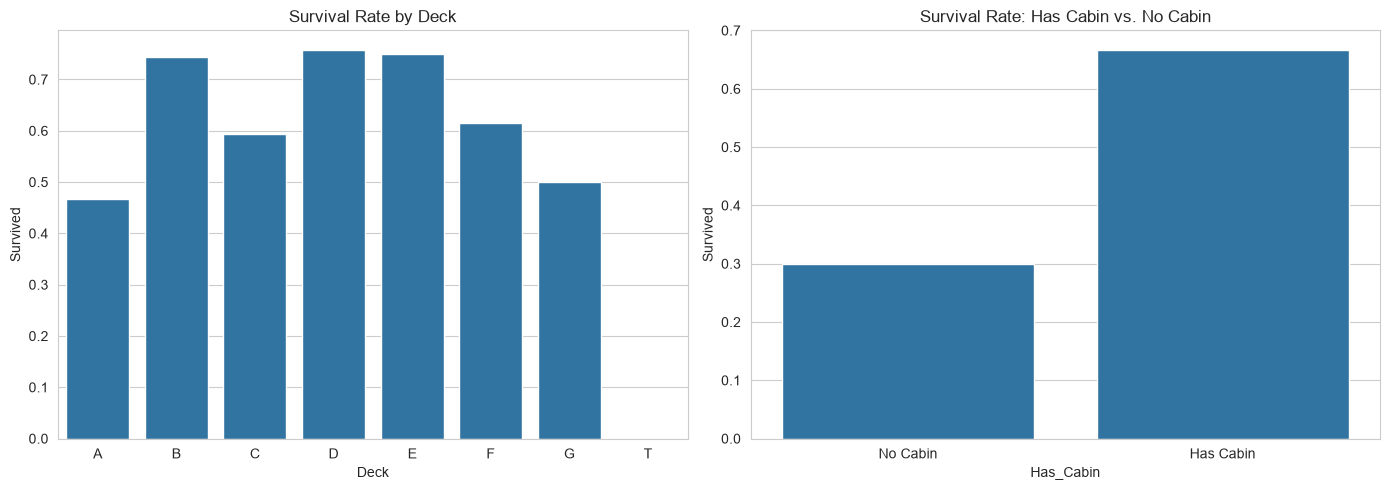

Has_Cabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

In [7]:
df_eda['Has_Cabin'] = df_eda['Cabin'].notnull().astype(int)
df_eda['Deck'] = df_eda['Cabin'].str[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
deck_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
sns.barplot(data=df_eda, x='Deck', y='Survived', order=deck_order, ax=axes[0], errorbar=None); axes[0].set_title('Survival Rate by Deck')
sns.barplot(data=df_eda, x='Has_Cabin', y='Survived', ax=axes[1], errorbar=None); axes[1].set_title('Survival Rate: Has Cabin vs. No Cabin')
axes[1].set_xticklabels(['No Cabin', 'Has Cabin'])
plt.tight_layout()
plt.show()

df_eda.groupby('Has_Cabin')['Survived'].mean()


**Findings:** Individual deck letters are noisy (small sample per deck, wide confidence intervals, e.g. Deck T has a single passenger). But **`Has_Cabin` shows a large, reliable gap (~0.30 vs. ~0.67 survival)**, backed by large sample sizes on both sides. This is a good example of a missing-value flag carrying more usable signal than the raw (sparse) values themselves. **Decision: engineer `Has_Cabin`, drop the raw `Cabin`/`Deck` columns.**


### 2.5 Statistical tests: chi-square & Cramér's V

In [8]:
def chi_square_test(df, col, target='Survived'):
    contingency = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"--- {col} vs {target} ---")
    print(f"Chi2: {chi2:.2f}   p-value: {p:.5f}   dof: {dof}")
    return chi2, p

def cramers_v(df, col1, col2):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

for col in ['Sex', 'Pclass', 'Embarked', 'Has_Cabin']:
    chi_square_test(df_eda, col)
    v = cramers_v(df_eda, col, 'Survived')
    print(f"Cramer's V: {v:.3f}\n")


--- Sex vs Survived ---
Chi2: 260.72   p-value: 0.00000   dof: 1
Cramer's V: 0.541

--- Pclass vs Survived ---
Chi2: 102.89   p-value: 0.00000   dof: 2
Cramer's V: 0.340

--- Embarked vs Survived ---
Chi2: 26.49   p-value: 0.00000   dof: 2
Cramer's V: 0.173

--- Has_Cabin vs Survived ---
Chi2: 87.94   p-value: 0.00000   dof: 1
Cramer's V: 0.314



All four features are statistically significant (p < 0.001), confirming genuine associations with `Survived` rather than noise. Cramér's V (an effect-size measure, unlike the p-value which is heavily influenced by sample size) shows **Sex** as by far the strongest association, **Pclass** and **Has_Cabin** as moderate, and **Embarked** as the weakest of the four, consistent with the correlation heatmap above.

**Important distinction:** statistical significance (p-value) tells us a relationship probably isn't due to chance, it does *not* tell us how strong or practically useful that relationship is. Effect size (Cramér's V, or correlation magnitude) is what tells us that.


### 2.6 Title: is this feature infromative?

`Title`, extracted from `Name`, is closely tied to `Sex` (Mr/Master are essentially always male, Miss/Mrs are essentially always female), but it adds a layer of detail that `Sex` alone doesn't capture, specifically age and marital/social status.

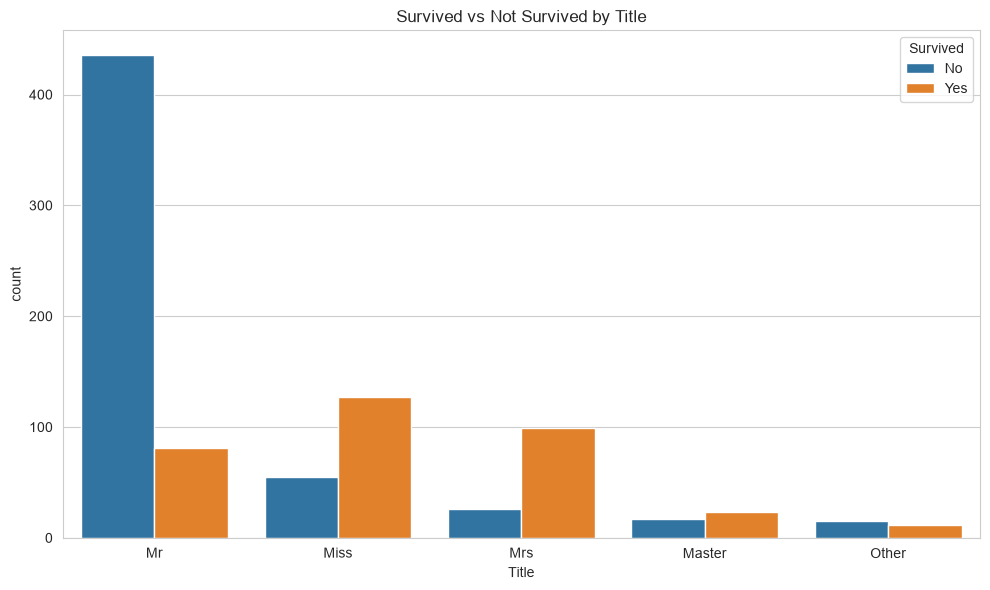

In [9]:
df_eda['Title'] = df_eda['Name'].str.extract(r',\s*([^\.]+)\.')

common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
df_eda['Title'] = df_eda['Title'].apply(lambda t: t if t in common_titles else 'Other')

plt.figure(figsize=(10, 6))
order = ['Mr', 'Miss', 'Mrs', 'Master', 'Other']
sns.countplot(data=df_eda, x='Title', hue='Survived', order=order)
plt.title('Survived vs Not Survived by Title')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

The plot above shows this clearly:
- **Mr** is the largest group by far and the overwhelming majority did not survive.
- **Miss** and **Mrs** both show a strong skew toward survival, consistent with the broader "women first" pattern already seen in `Sex`.
- **Master** (young boys) is a small group, but survivors outnumber non-survivors, distinct from the `Mr` pattern, even though both are male. This is exactly the nuance `Sex` alone cannot express: an adult man and a young boy get the same `Sex` value, but very different survival outcomes.
- **Other** (rare titles — Dr, Rev, Col, Lady, etc.) is a small, mixed bucket with no strong lean either way, and thin enough that its pattern shouldn't be over-interpreted.

**Conclusion:** `Title` is informative beyond what `Sex` alone provides. It's effectively "Sex plus a finer age/status signal" bundled into one categorical feature.

### 2.7 Target and feature balance

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


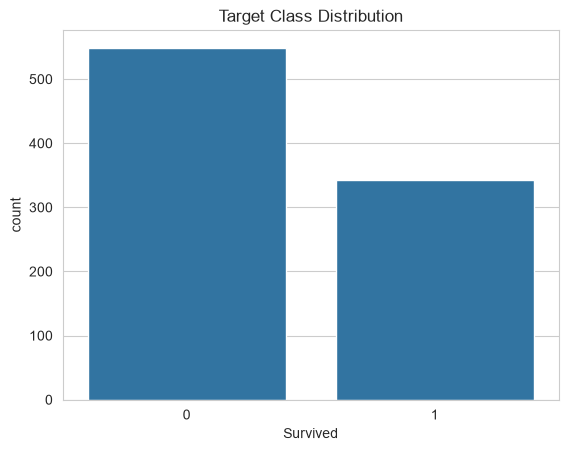

In [10]:
print(df_train['Survived'].value_counts())
print(df_train['Survived'].value_counts(normalize=True).round(3))

sns.countplot(data=df_train, x='Survived')
plt.title('Target Class Distribution')
plt.show()


`Survived` is roughly **62% / 38%** — mildly imbalanced, not severe. This is not extreme enough to need resampling techniques (e.g. SMOTE), but it does inform two choices later: using `stratify=` in the train/test split and `StratifiedKFold` for cross-validation, so the class ratio is preserved in every fold/split.


In [11]:
cat_cols = ['Sex', 'Pclass', 'Embarked', 'SibSp', 'Parch']
for col in cat_cols:
    print(f"--- {col} ---")
    print(df_train[col].value_counts(normalize=True).round(3))
    print()


--- Sex ---
Sex
male      0.648
female    0.352
Name: proportion, dtype: float64

--- Pclass ---
Pclass
3    0.551
1    0.242
2    0.207
Name: proportion, dtype: float64

--- Embarked ---
Embarked
S    0.724
C    0.189
Q    0.087
Name: proportion, dtype: float64

--- SibSp ---
SibSp
0    0.682
1    0.235
2    0.031
4    0.020
3    0.018
8    0.008
5    0.006
Name: proportion, dtype: float64

--- Parch ---
Parch
0    0.761
1    0.132
2    0.090
5    0.006
3    0.006
4    0.004
6    0.001
Name: proportion, dtype: float64



**Findings:** `Embarked` is dominated by 'S' (~72%), and `SibSp`/`Parch` have a long tail of rare values (5, 6, 8) with only a handful of rows each. Rare categories like these risk contributing noise rather than signal to a model (a tree could split on a single anecdotal example; a one-hot column that's `1` for 1-2 rows adds little generalizable information). **This motivates bucketing `SibSp`+`Parch` into a coarser `FamilyGroup` feature (see below) rather than using the raw counts directly.**


## 3. Data Cleaning & Feature Engineering

Bringing together everything the EDA justified:

- **`Has_Cabin`**: binary flag from `Cabin`, then drop the raw (sparse, noisy) `Cabin` column.
- **`Age`**: impute missing values using the **median per `Pclass`** (age distributions clearly differ by class — see EDA above), rather than a single global mean/median.
- **`Embarked`**: fill the 2 missing values with the mode (negligible impact either way).
- **`FamilyGroup`**: bucket `SibSp + Parch + 1` into `Alone` / `Small` (2-4) / `Large` (5+) — this both avoids the rare-value sparsity problem and lets a *linear* model represent the non-monotonic (U-shaped) relationship between family size and survival that a single numeric coefficient cannot.
- **`Title`**: extracted from `Name` (Mr/Mrs/Miss/Master/Other) — often more predictive than raw `Age`/`Sex` alone, since it encodes age/marital-status nuance (e.g. "Master" reliably identifies young boys).
- **`Fare_log`**: log-transform of `Fare` to tame its right-skew/outliers — primarily useful for the linear model; tree-based models are unaffected by monotonic transforms.
- Drop `PassengerId`, `Name`, `Ticket`, and the raw `SibSp`/`Parch` (superseded by `FamilyGroup`).


In [12]:
df_clean = df_train.copy()

# Has_Cabin
df_clean['Has_Cabin'] = df_clean['Cabin'].notnull().astype(int)
df_clean.drop(columns=['Cabin'], inplace=True)

# Age: median per Pclass
df_clean['Age'] = df_clean.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# FamilyGroup
def bucket_family_size(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

df_clean['FamilyGroup'] = (df_clean['SibSp'] + df_clean['Parch'] + 1).apply(bucket_family_size)

# Title
df_clean['Title'] = df_clean['Name'].str.extract(r',\s*([^\.]+)\.')
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
df_clean['Title'] = df_clean['Title'].apply(lambda t: t if t in common_titles else 'Other')

# Fare_log
df_clean['Fare_log'] = np.log1p(df_clean['Fare'])
df_clean.drop(columns=['Fare'], inplace=True)

# Drop redundant columns
df_clean.drop(columns=['PassengerId', 'Name', 'Ticket', 'Parch', 'SibSp'], inplace=True)

# One-hot encode categoricals
df_model = pd.get_dummies(df_clean, columns=['Sex', 'Embarked', 'FamilyGroup', 'Title'], drop_first=True)

# Sanity checks
print('Missing values remaining:', df_model.isnull().sum().sum())
print('Duplicate rows:', df_model.duplicated().sum())
print('Shape:', df_model.shape)
df_model.head()


Missing values remaining: 0
Duplicate rows: 107
Shape: (891, 14)


,Survived,Pclass,Age,Has_Cabin,Fare_log,Sex_male,Embarked_Q,Embarked_S,FamilyGroup_Large,FamilyGroup_Small,Title_Miss,Title_Mr,Title_Mrs,Title_Other
0,0,3,22.0,0,2.110213,True,False,True,False,True,False,True,False,False
1,1,1,38.0,1,4.280593,False,False,False,False,True,False,False,True,False
2,1,3,26.0,0,2.188856,False,False,True,False,False,True,False,False,False
3,1,1,35.0,1,3.990834,False,False,True,False,True,False,False,True,False
4,0,3,35.0,0,2.202765,True,False,True,False,False,False,True,False,False


## 4. Baseline Model: `LinearSVC`

### 4.1 Train/validation split and scaling

We use a **stratified split** (preserves the ~62/38 `Survived` ratio in both sets) and fit the `StandardScaler` **only on the training data**, then apply it (transform-only) to the validation data. Fitting the scaler on the full dataset before splitting would leak validation-set information into the "training" statistics, a subtle form of data leakage.


In [13]:
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_cols = ['Age', 'Fare_log', 'FamilySize'] if 'FamilySize' in X.columns else ['Age', 'Fare_log']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])


### 4.2 Fit & evaluate the baseline model

In [14]:
svc_model = LinearSVC(random_state=42, max_iter=10000)
svc_model.fit(X_train, y_train)

y_pred = svc_model.predict(X_val)
print('Accuracy:', accuracy_score(y_val, y_pred))
print()
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))


Accuracy: 0.8379888268156425

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       110
           1       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

[[97 13]
 [16 53]]


### 4.3 Cross-validation sanity check

In [15]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

X_scaled = X.copy()
X_scaled[numeric_cols] = StandardScaler().fit_transform(X_scaled[numeric_cols])

cv_scores = cross_val_score(LinearSVC(random_state=42, max_iter=10000), X_scaled, y, cv=skf, scoring='accuracy')
print('CV scores:', cv_scores)
print('Mean CV accuracy:', cv_scores.mean(), '  Std:', cv_scores.std())


CV scores: [0.86666667 0.80898876 0.82022472 0.80898876 0.82022472 0.85393258
 0.85393258 0.80898876 0.84269663 0.84269663]
Mean CV accuracy: 0.8327340823970036   Std: 0.020623207043783908


A single train/validation split can be misleadingly lucky or unlucky, especially with a dataset this size (~180-row validation set). Cross-validation confirms whether the single-split score is representative and a tight spread across folds means we can trust the estimate.


## 5. Hyperparameter Tuning — `LinearSVC`

### 5.1 Manual sweep over `C`


In [16]:
for C_val in [0.01, 0.1, 0.5, 1, 2, 5, 10]:
    m = LinearSVC(C=C_val, random_state=42, max_iter=10000)
    scores = cross_val_score(m, X_scaled, y, cv=skf, scoring='accuracy')
    print(f"C={C_val}: mean CV accuracy = {scores.mean():.4f}, std = {scores.std():.4f}")


C=0.01: mean CV accuracy = 0.8159, std = 0.0344
C=0.1: mean CV accuracy = 0.8282, std = 0.0217
C=0.5: mean CV accuracy = 0.8305, std = 0.0194
C=1: mean CV accuracy = 0.8327, std = 0.0206
C=2: mean CV accuracy = 0.8327, std = 0.0206
C=5: mean CV accuracy = 0.8327, std = 0.0206
C=10: mean CV accuracy = 0.8327, std = 0.0206


**Finding:** accuracy plateaus (flat, identical scores) across roughly `C=0.5` to `C=5`. The model has found a stable decision boundary in that range and `C` alone is not the bottleneck to further improvement. Very low `C` (0.01) clearly underfits.


### 5.2 `RandomizedSearchCV`

In [17]:
from scipy.stats import uniform

param_dist = {
    'C': uniform(0.001, 10),
    'class_weight': [None, 'balanced'],
    'loss': ['hinge', 'squared_hinge']
}

random_search = RandomizedSearchCV(
    LinearSVC(random_state=42, max_iter=10000),
    param_distributions=param_dist,
    n_iter=50,
    scoring='accuracy',
    cv=skf,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_scaled, y)
print('Best params:', random_search.best_params_)
print('Best CV score:', random_search.best_score_)


Best params: {'C': np.float64(4.56169984217036), 'class_weight': None, 'loss': 'squared_hinge'}
Best CV score: 0.8327340823970036


### 5.3 `GridSearchCV` (narrow grid around the random-search result)

In [18]:
param_grid = {
    'C': np.arange(1, 8, 0.5),
    'class_weight': [None, 'balanced'],
    'loss': ['hinge', 'squared_hinge']
}

grid_search = GridSearchCV(
    LinearSVC(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='accuracy',
    cv=skf,
    n_jobs=-1
)
grid_search.fit(X_scaled, y)
print('Best params:', grid_search.best_params_)
print('Best CV score:', grid_search.best_score_)


Best params: {'C': np.float64(1.0), 'class_weight': None, 'loss': 'squared_hinge'}
Best CV score: 0.8327340823970036


**Finding:** hyperparameter tuning (manual, randomized, and grid search) all converge on the same conclusion, and accuracy sits at a plateau around **0.81-0.83** regardless of `C`, `class_weight`, or `loss`, once `C` is above a small threshold. This tells us the *model configuration* is not the limiting factor here and the bottleneck is the **information available in the features**. The best parameters resulted are also in fact the default parameters.


### 5.4 Final tuned `LinearSVC`: classification report & ROC-AUC

Accuracy: 0.8379888268156425

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       110
           1       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

[[97 13]
 [16 53]]
CV scores: [0.86666667 0.80898876 0.82022472 0.80898876 0.82022472 0.85393258
 0.85393258 0.80898876 0.84269663 0.84269663]
Mean CV accuracy: 0.8327340823970036   Std: 0.020623207043783908
AUC-ROC: 0.8620553359683794


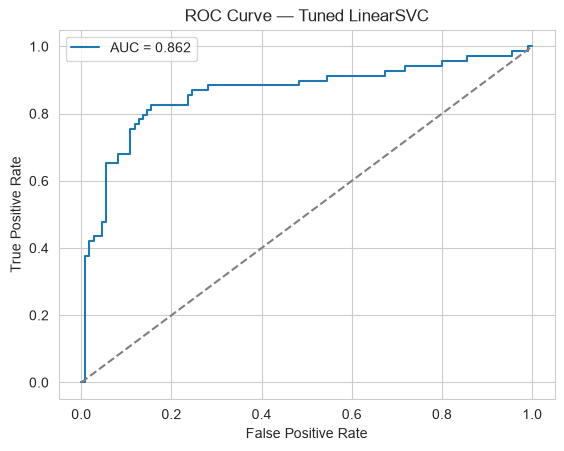

In [19]:
final_svc = LinearSVC(C=1.0, class_weight=None, loss='squared_hinge', random_state=42, max_iter=10000)
final_svc.fit(X_train, y_train)

y_pred_final = final_svc.predict(X_val)
print('Accuracy:', accuracy_score(y_val, y_pred_final))
print()
print(classification_report(y_val, y_pred_final))
print(confusion_matrix(y_val, y_pred_final))

cv_scores = cross_val_score(LinearSVC(random_state=42, max_iter=10000), X_scaled, y, cv=skf, scoring='accuracy')
print('CV scores:', cv_scores)
print('Mean CV accuracy:', cv_scores.mean(), '  Std:', cv_scores.std())

y_scores_final = final_svc.decision_function(X_val)
auc_final = roc_auc_score(y_val, y_scores_final)
print('AUC-ROC:', auc_final)

fpr, tpr, _ = roc_curve(y_val, y_scores_final)
plt.plot(fpr, tpr, label=f'AUC = {auc_final:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Tuned LinearSVC')
plt.legend()
plt.show()


### 5.5 Model coefficients

In [20]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': final_svc.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
coef_df


,feature,coefficient
7,FamilyGroup_Large,-1.148854
10,Title_Mr,-1.012422
12,Title_Other,-0.678037
4,Sex_male,-0.606334
9,Title_Miss,-0.590051
11,Title_Mrs,-0.336803
2,Has_Cabin,0.306372
0,Pclass,-0.151209
1,Age,-0.131745
3,Fare_log,0.121191



With `Sex`, `Title`, and `FamilyGroup` all included together, the coefficients tell a consistent, but slightly more nuanced, story than any single feature did on its own.


- **`FamilyGroup_Large` (-1.15)** — the single largest coefficient in the model. Being in a large family (5+ members) sharply reduces predicted survival odds relative to the baseline. This matches the EDA bar plot, where large families showed a steep survival drop-off and it's a good example of why bucketing was necessary in the first place. A plain linear `FamilySize` coefficient could never isolate this effect on its own, since the true relationship is non-monotonic (dips at "Alone", peaks at "Small", drops again at "Large").
- **`Title_Mr` (-1.01)** and **`Sex_male` (-0.61)** — both strongly negative, both pushing toward "did not survive." This is where multicollinearity is visible directly.  `Title_Mr` and `Sex_male` overlap heavily, so the model is splitting the "adult male" signal across two correlated coefficients rather than attributing it cleanly to one. The *combined* negative effect of being an adult man is real and large, but the exact split between these two numbers shouldn't be read too literally and regularization (`C=1.0`) keeps both from blowing up, but it doesn't remove the underlying redundancy, just tempers its effect on stability.
- **`Title_Other` (-0.68)** — moderately negative. This bucket groups a handful of rare titles (Dr, Rev, Col, Lady, etc.) with too few observations individually to model separately. The aggregate leans toward lower survival, but with a small, heterogeneous sample behind it, this coefficient carries more uncertainty than the others.


- **`Sex_male`, `Title_Miss` (-0.59), `Title_Mrs` (-0.34)** — the negative sign for `Title_Miss`/`Title_Mrs` looks surprising at first (women should have *higher* survival), but this is exactly the multicollinearity risk in action: since `Sex_male` already carries most of the "being female helps" signal as its *inverse*, the `Title` dummies for female titles are picking up smaller, residual effects relative to each other rather than the full female-survival boost, which is now mostly absorbed into the (large, negative) `Sex_male` coefficient. Interpreting `Title_Miss`/`Title_Mrs` in isolation, without reference to `Sex_male`, would be misleading.
- **`Has_Cabin` (0.31)** and **`Pclass` (-0.15)** — both consistent in direction and magnitude with earlier single-feature analysis, having a recorded cabin helps, higher `Pclass` number (lower class) hurts.


**Conclusion, with the multicollinearity caveat in mind:**

The ranking of *combined, related* effects — family size, gender/title, class/cabin — matches the EDA's findings almost exactly: `Sex`/`Title` and `FamilyGroup_Large` dominate, `Pclass`/`Has_Cabin` matter moderately, and `Embarked`/`Fare` contribute only marginally. However, because `Sex` and `Title` are collinear, **individual coefficients among that group (`Sex_male`, `Title_Mr`, `Title_Miss`, `Title_Mrs`) should be read as a cluster, not as independent, additive effects**. The model's *overall* reliance on "gender and title information" is clearly large and reliable, but exactly how much credit belongs to `Sex` versus `Title` specifically is not something these coefficients can cleanly answer.

## 6. Tree-Based Model: `RandomForestClassifier`

Trees can capture feature *interactions* (e.g. "male AND 3rd class" being worse than what "male" and "3rd class" would separately predict) that a linear model structurally cannot. Trees are also scale- and monotonic-transform-invariant, so `Fare_log`/scaling are unnecessary here so raw `Fare`, `FamilySize` and `Title` work identically well.



In [21]:
# Raw (non-bucketed) feature set for the tree model
df_raw = df_train.copy()

df_raw['Has_Cabin'] = df_raw['Cabin'].notnull().astype(int)
df_raw.drop(columns=['Cabin'], inplace=True)

df_raw['Age'] = df_raw.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
df_raw['Embarked'] = df_raw['Embarked'].fillna(df_raw['Embarked'].mode()[0])

df_raw['FamilySize'] = df_raw['SibSp'] + df_raw['Parch'] + 1
df_raw['Title'] = df_raw['Name'].str.extract(r',\s*([^\.]+)\.')

df_raw.drop(columns=['PassengerId', 'Name', 'Ticket', 'Parch', 'SibSp'], inplace=True)
df_raw = pd.get_dummies(df_raw, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

X_raw = df_raw.drop(columns=['Survived'])
y_raw = df_raw['Survived']

print(X_raw.shape)
X_raw.columns.tolist()


(891, 24)


['Pclass',
 'Age',
 'Fare',
 'Has_Cabin',
 'FamilySize',
 'Sex_male',
 'Embarked_Q',
 'Embarked_S',
 'Title_Col',
 'Title_Don',
 'Title_Dr',
 'Title_Jonkheer',
 'Title_Lady',
 'Title_Major',
 'Title_Master',
 'Title_Miss',
 'Title_Mlle',
 'Title_Mme',
 'Title_Mr',
 'Title_Mrs',
 'Title_Ms',
 'Title_Rev',
 'Title_Sir',
 'Title_the Countess']

In [22]:
# Untuned baseline
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
cv_scores_rf = cross_val_score(rf_baseline, X_raw, y_raw, cv=skf, scoring='accuracy')
print('Untuned RandomForest mean CV accuracy:', cv_scores_rf.mean())


Untuned RandomForest mean CV accuracy: 0.8249063670411985


**Finding:** the untuned forest (~0.82 accuracy) doesn't automatically beat the tuned linear model and is likely overfitting on this small dataset (~900 rows) with unconstrained tree depth. Tuning (constraining depth, minimum samples per split/leaf) is necessary before drawing conclusions.


### 6.1 Hyperparameter tuning (`RandomizedSearchCV`)

In [23]:
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_raw, y_raw)
print('Best params:', rf_search.best_params_)
print('Best CV score:', rf_search.best_score_)


Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
Best CV score: 0.8406126420187057


### 6.2 Final tuned Random Forest: classification report, ROC-AUC, feature importance

Accuracy: 0.8156424581005587

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179

[[98 12]
 [21 48]]
AUC-ROC: 0.8471014492753622


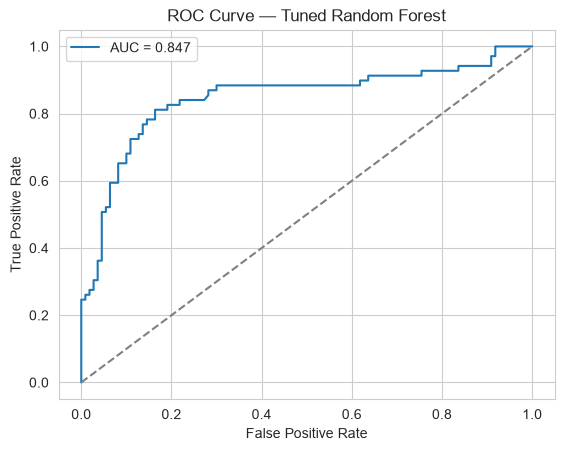

In [24]:
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

rf_final = RandomForestClassifier(**rf_search.best_params_, random_state=42, n_jobs=-1)
rf_final.fit(X_train_raw, y_train_raw)

y_pred_rf = rf_final.predict(X_val_raw)
print('Accuracy:', accuracy_score(y_val_raw, y_pred_rf))
print()
print(classification_report(y_val_raw, y_pred_rf))
print(confusion_matrix(y_val_raw, y_pred_rf))

y_proba_rf = rf_final.predict_proba(X_val_raw)[:, 1]
auc_rf = roc_auc_score(y_val_raw, y_proba_rf)
print('AUC-ROC:', auc_rf)

fpr_rf, tpr_rf, _ = roc_curve(y_val_raw, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'AUC = {auc_rf:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Tuned Random Forest')
plt.legend()
plt.show()


In [25]:
importance_df = pd.DataFrame({
    'feature': X_train_raw.columns,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

importance_df


,feature,importance
18,Title_Mr,0.195725
2,Fare,0.161171
5,Sex_male,0.159847
1,Age,0.110085
0,Pclass,0.089657
4,FamilySize,0.070523
3,Has_Cabin,0.063291
19,Title_Mrs,0.047135
15,Title_Miss,0.047101
7,Embarked_S,0.021583


**Findings:**
- `Title_Mr` and `Sex_male` come out roughly tied at the top. The multicollinearity discussed earlier shows up here as the forest splitting "credit" for the same underlying signal across both correlated features (trees handle this gracefully, unlike linear coefficients).
- `Fare` ranks higher here than in the linear model's coefficients because trees exploit fine-grained, non-linear variation in `Fare` *within* each `Pclass` that a single linear coefficient can't capture as efficiently.
- `Age` similarly ranks higher. A tree can carve out the "young child" survival bump as a specific threshold split.
- `Embarked_S`/`Embarked_Q`/rare `Title` categories rank lowest, consistent with the EDA.

Despite very different model types and different importance/coefficient metrics, the **same core drivers** (sex/title, class/fare, age, family size) surface consistently, which is good evidence the model is capturing genuine structure in the data, rather than not overfitting to noise.


## 7. Summary & Results

| Model | Mean CV Accuracy |
|---|---|
| LinearSVC (untuned) | ~0.833 |
| LinearSVC (tuned: `C`, `class_weight`, `loss`) | ~0.833 |
|  RandomForest (untuned) | ~0.825 |
| **RandomForest (tuned)**| **~0.847** |


**Key takeaways from this analysis:**

1. **Sex is the single strongest predictor of survival**, confirmed consistently across correlation, chi-square/Cramér's V, linear coefficients, and tree feature importance.
2. **Passenger class and fare** (proxies for socioeconomic status) are the next most important signals, along with the engineered `Has_Cabin`/`Title` features that captured related information the raw columns didn't expose directly.
3. **A well-tuned linear model and a well-tuned tree ensemble ended up performing similarly** (~0.83-0.84), suggesting this dataset, with this feature set, has a practical accuracy ceiling in that range regardless of model family, so further large gains would likely require more data or new information (e.g. ticket-sharing groups, fare-per-person) rather than more modeling effort.
